# Notification Priority Classification — Feature Extraction


1. **TF-IDF features** — sparse bag-of-words/bigrams representation used for the baseline model
2. **BERT tokenisation statistics** — token length analysis to validate our `max_len` choice
3. **BERT [CLS] embeddings** — dense semantic representations from pre-trained `bert-base-uncased`,
   visualised with t-SNE to confirm class separability before fine-tuning

## 1. Imports & Setup

In [1]:
import os
import sys
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# Paths relative to the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures'

MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Consistent urgency colours matching the existing paper figures
URGENCY_COLORS = {'high': '#E74C3C', 'medium': '#F39C12', 'low': '#2ECC71'}
LABEL_ORDER    = ['high', 'medium', 'low']
LABEL_DISPLAY  = {'high': 'High', 'medium': 'Medium', 'low': 'Low'}

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Project root:', PROJECT_ROOT)
print('Data dir:    ', DATA_DIR)
print('Models dir:  ', MODELS_DIR)
print('Figures dir: ', FIGURES_DIR)

Project root: /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis
Data dir:     /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/data/processed
Models dir:   /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/models
Figures dir:  /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/results/figures


## 2. Load Preprocessed Splits

In [2]:
train_df = pd.read_csv(DATA_DIR / 'notifications_train.csv')
val_df   = pd.read_csv(DATA_DIR / 'notifications_val.csv')
test_df  = pd.read_csv(DATA_DIR / 'notifications_test.csv')

# Normalise label case (CSV has lowercase 'high'/'medium'/'low')
for df in (train_df, val_df, test_df):
    df['urgency'] = df['urgency'].str.lower().str.strip()

print(f'Train: {len(train_df):>4} rows | Val: {len(val_df):>3} rows | Test: {len(test_df):>3} rows')
print('\nUrgency distribution (train):')
print(train_df['urgency'].value_counts())

# Use notif_content as the model input text (title-level field already
# contains the full notification text in our curated dataset)
X_train = train_df['notif_content'].fillna('').tolist()
X_val   = val_df['notif_content'].fillna('').tolist()
X_test  = test_df['notif_content'].fillna('').tolist()

y_train = train_df['urgency'].tolist()
y_val   = val_df['urgency'].tolist()
y_test  = test_df['urgency'].tolist()

# All texts (train + val + test) used only for embedding extraction
all_texts  = X_train + X_val + X_test
all_labels = y_train + y_val + y_test

Train:  519 rows | Val: 109 rows | Test: 109 rows

Urgency distribution (train):
urgency
low       199
high      182
medium    138
Name: count, dtype: int64


---
## 3. TF-IDF Feature Extraction

We fit a TF-IDF vectoriser **only on the training set** to avoid data leakage, then transform
the validation and test sets.  We use unigrams and bigrams (`ngram_range=(1,2)`) because urgency
is often expressed through short phrases (e.g. "payment failed", "verify now").
`sublinear_tf=True` applies log-scaling to term frequencies, which helps on the short notification
texts in our dataset.

In [3]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    sublinear_tf=True,
    min_df=2,           # ignore terms appearing in fewer than 2 training docs
    strip_accents='unicode',
    lowercase=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit ONLY on train
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

vocab_size = len(tfidf.vocabulary_)
print(f'TF-IDF vocabulary size : {vocab_size} features')
print(f'Train matrix shape     : {X_train_tfidf.shape}')
print(f'Val   matrix shape     : {X_val_tfidf.shape}')
print(f'Test  matrix shape     : {X_test_tfidf.shape}')

# Save vectoriser for use in the modelling notebook
vectorizer_path = MODELS_DIR / 'tfidf_vectorizer.pkl'
with open(vectorizer_path, 'wb') as f:
    pickle.dump(tfidf, f)
print(f'\nVectoriser saved to {vectorizer_path}')

TF-IDF vocabulary size : 500 features
Train matrix shape     : (519, 500)
Val   matrix shape     : (109, 500)
Test  matrix shape     : (109, 500)

Vectoriser saved to /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/models/tfidf_vectorizer.pkl


### 3.1 Top TF-IDF Terms per Urgency Class

For each class we compute the **mean TF-IDF weight** across all training documents of that class
and display the 15 highest-scoring terms.

In [4]:
feature_names = np.array(tfidf.get_feature_names_out())
TOP_N = 15

top_terms = {}
for label in LABEL_ORDER:
    mask = np.array(y_train) == label
    class_matrix = X_train_tfidf[mask]          # sparse submatrix for this class
    mean_weights = np.asarray(class_matrix.mean(axis=0)).flatten()
    top_idx = np.argsort(mean_weights)[::-1][:TOP_N]
    top_terms[label] = list(zip(feature_names[top_idx], mean_weights[top_idx]))

print('Top 10 TF-IDF terms per class (term : mean weight)\n')
for label in LABEL_ORDER:
    print(f'  {LABEL_DISPLAY[label]}:')
    for term, w in top_terms[label][:10]:
        print(f'    {term:<30} {w:.4f}')
    print()

Top 10 TF-IDF terms per class (term : mean weight)

  High:
    your                           0.0756
    to                             0.0592
    minutes                        0.0575
    in                             0.0446
    is                             0.0423
    code                           0.0406
    am                             0.0331
    the                            0.0328
    account                        0.0315
    00                             0.0293

  Medium:
    you                            0.0646
    your                           0.0594
    is                             0.0585
    the                            0.0466
    from                           0.0434
    in                             0.0408
    for                            0.0372
    pm                             0.0328
    at                             0.0318
    available                      0.0310

  Low:
    name                           0.0707
    your                           0.05

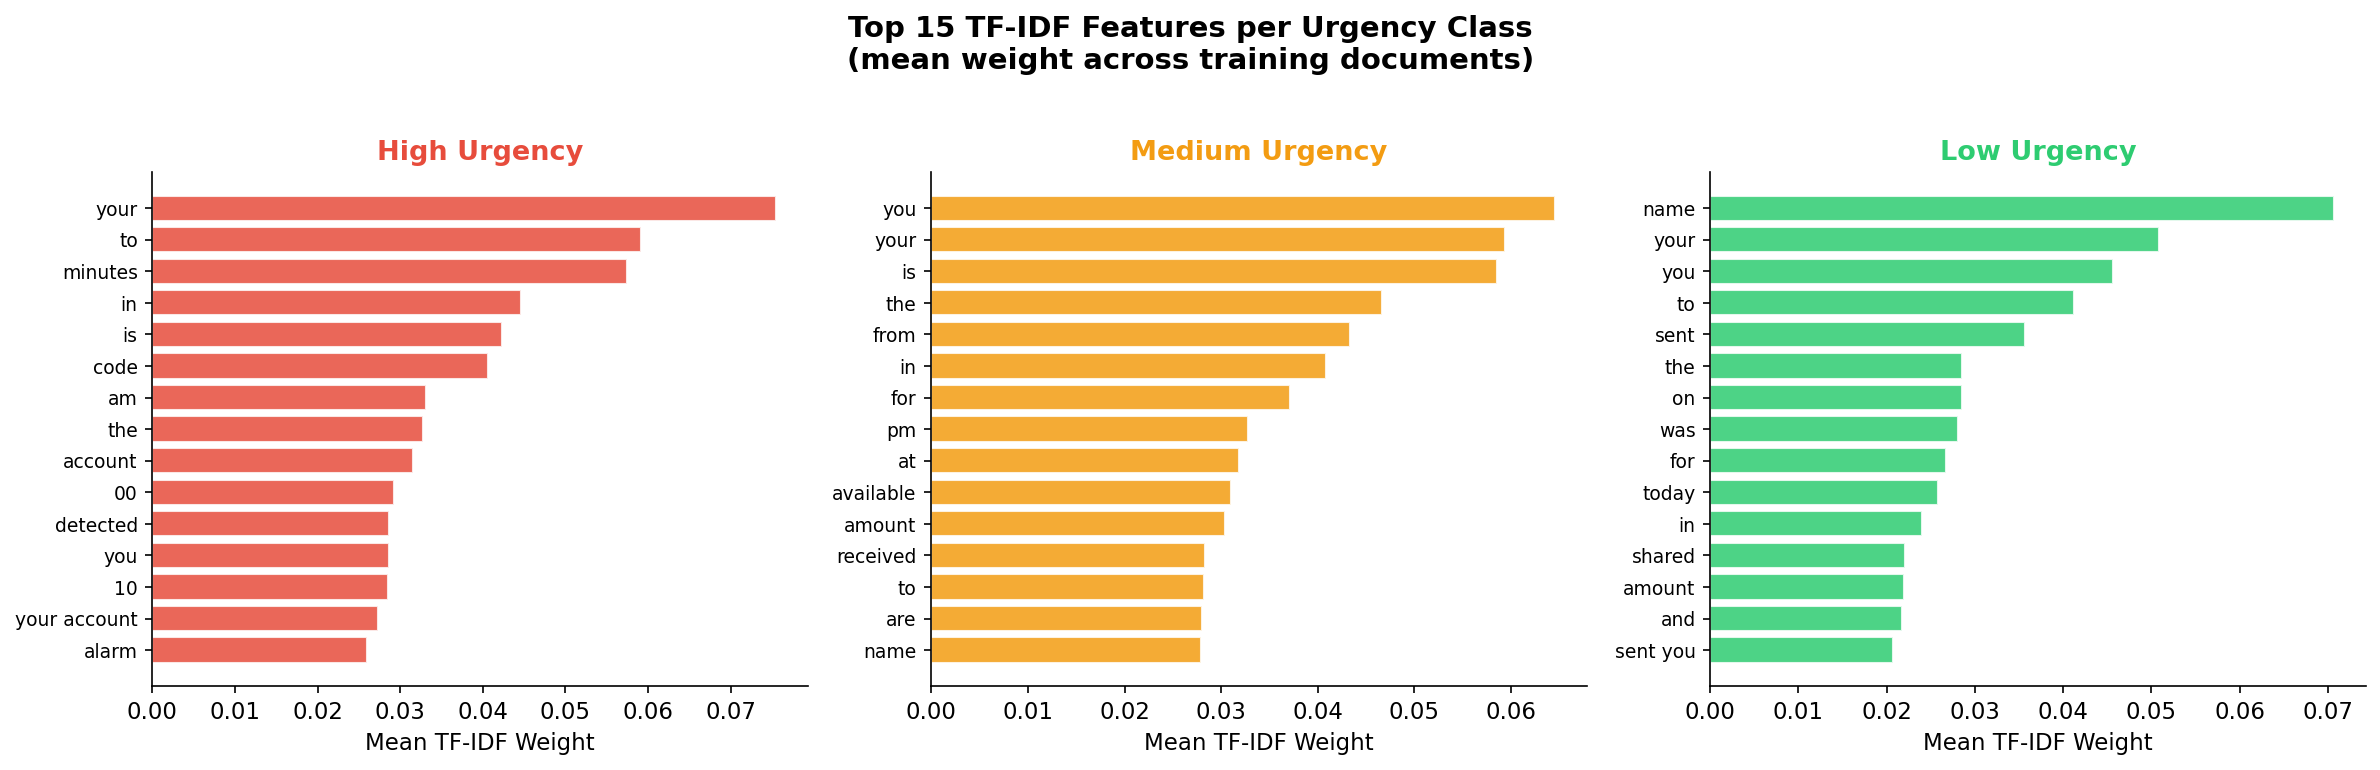

Figure 7 saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top 15 TF-IDF Features per Urgency Class\n(mean weight across training documents)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, label in zip(axes, LABEL_ORDER):
    terms, weights = zip(*top_terms[label])
    y_pos = np.arange(len(terms))
    bars = ax.barh(y_pos, weights, color=URGENCY_COLORS[label], alpha=0.85, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()   # highest weight at the top
    ax.set_title(f'{LABEL_DISPLAY[label]} Urgency', fontweight='bold',
                 color=URGENCY_COLORS[label])
    ax.set_xlabel('Mean TF-IDF Weight')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

for ext in ('svg', 'png', 'pdf'):
    fig.savefig(FIGURES_DIR / f'fig7_tfidf_top_features.{ext}',
                bbox_inches='tight', format=ext)
plt.show()
print('Figure 7 saved.')

---
## 4. BERT Tokenisation Analysis

We use the `bert-base-uncased` tokeniser (WordPiece) to measure how many tokens each notification
produces.  This determines the `max_len` hyper-parameter for fine-tuning: we want a value that
covers the vast majority of notifications without unnecessary padding.

In [6]:
try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print('Tokeniser loaded: bert-base-uncased')
except ImportError:
    raise ImportError('Install transformers: pip install transformers')

Tokeniser loaded: bert-base-uncased


In [7]:
# Tokenise every notification (all splits) and record token lengths
token_lengths = []
for text in all_texts:
    ids = tokenizer.encode(str(text), add_special_tokens=True)  # includes [CLS] and [SEP]
    token_lengths.append(len(ids))

token_lengths = np.array(token_lengths)

print(f'Token length statistics (all {len(all_texts)} notifications):')
print(f'  Min    : {token_lengths.min()}')
print(f'  Max    : {token_lengths.max()}')
print(f'  Mean   : {token_lengths.mean():.1f}')
print(f'  Median : {np.median(token_lengths):.0f}')
print(f'  Std    : {token_lengths.std():.1f}')
print()
for pct in (90, 95, 99, 100):
    val = np.percentile(token_lengths, pct)
    print(f'  {pct}th percentile : {val:.0f} tokens')

Token length statistics (all 737 notifications):
  Min    : 3
  Max    : 98
  Mean   : 15.4
  Median : 15
  Std    : 7.2

  90th percentile : 23 tokens
  95th percentile : 25 tokens
  99th percentile : 38 tokens
  100th percentile : 98 tokens


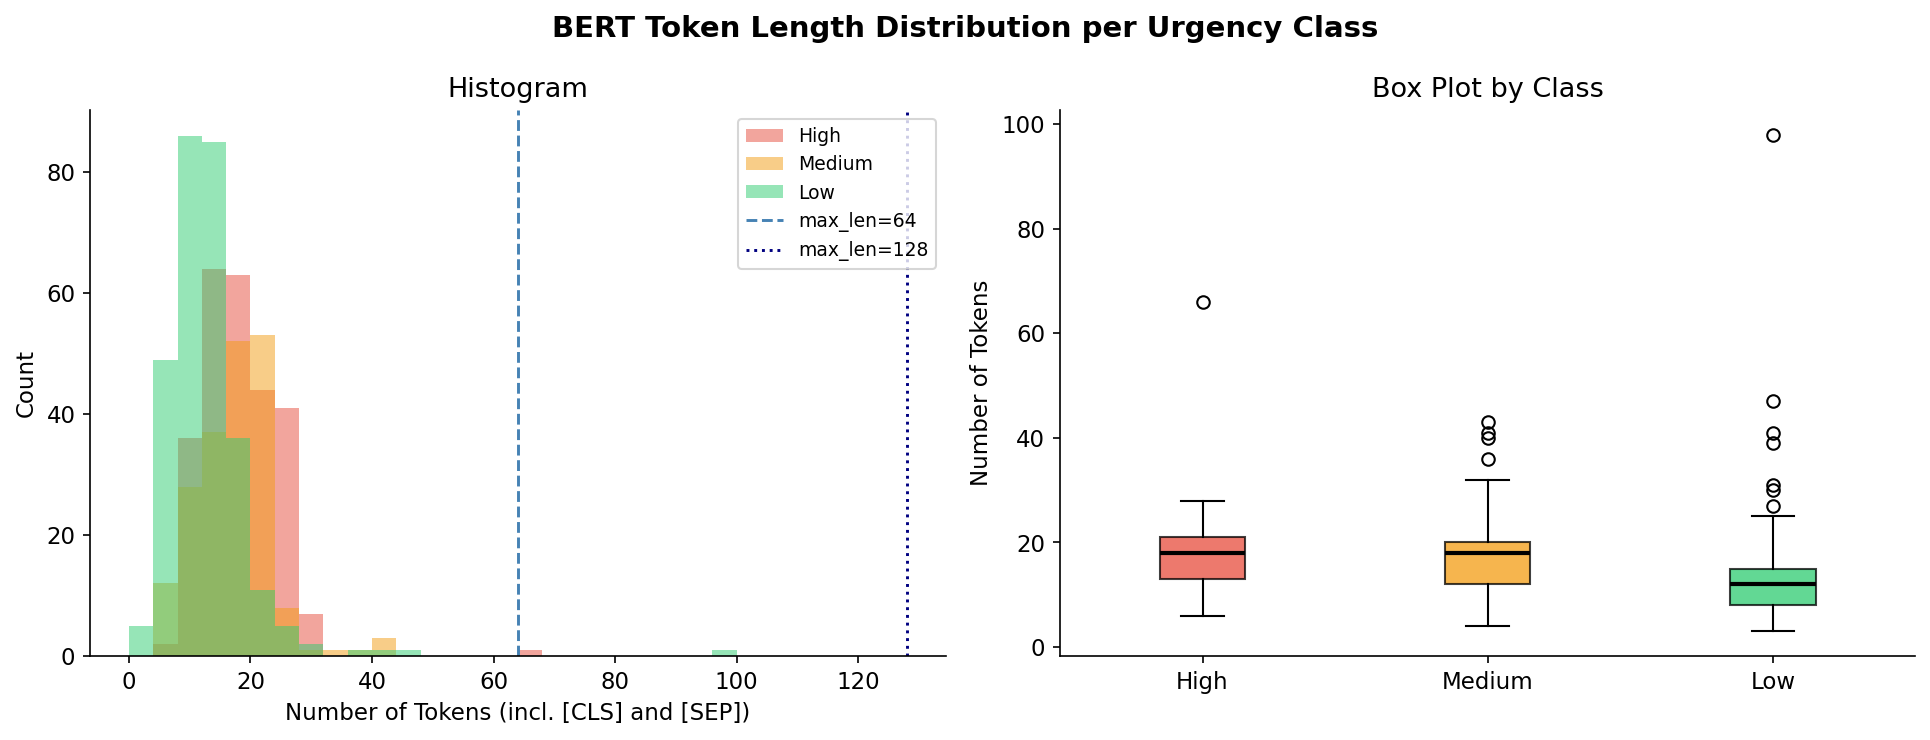

Figure 8 saved.


In [8]:
# Per-class token length distributions
lengths_by_class = {label: [] for label in LABEL_ORDER}
for text, label in zip(all_texts, all_labels):
    ids = tokenizer.encode(str(text), add_special_tokens=True)
    lengths_by_class[label].append(len(ids))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BERT Token Length Distribution per Urgency Class',
             fontsize=14, fontweight='bold')

# Left: overlapping histograms
ax = axes[0]
bins = np.arange(0, max(token_lengths) + 5, 4)
for label in LABEL_ORDER:
    ax.hist(lengths_by_class[label], bins=bins,
            color=URGENCY_COLORS[label], alpha=0.5,
            label=LABEL_DISPLAY[label], edgecolor='none')
ax.axvline(64,  color='steelblue', linestyle='--', linewidth=1.4, label='max_len=64')
ax.axvline(128, color='navy',      linestyle=':',  linewidth=1.4, label='max_len=128')
ax.set_xlabel('Number of Tokens (incl. [CLS] and [SEP])')
ax.set_ylabel('Count')
ax.set_title('Histogram')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: box-plot per class
ax2 = axes[1]
data_to_plot = [lengths_by_class[l] for l in LABEL_ORDER]
bp = ax2.boxplot(data_to_plot, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, label in zip(bp['boxes'], LABEL_ORDER):
    patch.set_facecolor(URGENCY_COLORS[label])
    patch.set_alpha(0.75)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels([LABEL_DISPLAY[l] for l in LABEL_ORDER])
ax2.set_ylabel('Number of Tokens')
ax2.set_title('Box Plot by Class')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ('svg', 'png', 'pdf'):
    fig.savefig(FIGURES_DIR / f'fig8_token_length_distribution.{ext}',
                bbox_inches='tight', format=ext)
plt.show()
print('Figure 8 saved.')

---
## 5. BERT [CLS] Embedding Extraction & t-SNE Visualisation

We pass every notification through **pre-trained `bert-base-uncased`** (no fine-tuning) and
extract the `[CLS]` token's last-hidden-state vector (768 dimensions).  These embeddings encode
general semantic meaning from BERT's pre-training.  We then project them to 2-D with t-SNE to
check whether the three urgency classes are already separable in the raw embedding space — which
would confirm that fine-tuning has a good starting point.


In [9]:
import torch
from transformers import AutoModel

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
MAX_LEN    = 64

print(f'Device: {DEVICE}')

model = AutoModel.from_pretrained('bert-base-uncased')
model.eval()
model.to(DEVICE)
print('bert-base-uncased loaded.')

Device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


bert-base-uncased loaded.


In [10]:
def extract_cls_embeddings(texts, tokenizer, model, batch_size=32, max_len=64, device='cpu'):
    """Return an (N, 768) numpy array of [CLS] last-hidden-state vectors."""
    all_embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start: start + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt',
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
        # outputs.last_hidden_state: (batch, seq_len, 768) — take [CLS] at position 0
        cls_vectors = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_vectors)
        if (start // batch_size) % 5 == 0:
            print(f'  Processed {min(start + batch_size, n)}/{n} samples...')
    return np.vstack(all_embeddings)


print('Extracting CLS embeddings (this may take a few minutes on CPU)...')
embeddings = extract_cls_embeddings(
    [str(t) for t in all_texts], tokenizer, model,
    batch_size=BATCH_SIZE, max_len=MAX_LEN, device=DEVICE
)
print(f'Embeddings shape: {embeddings.shape}')  # expected: (737, 768)

# Persist so we don't need to re-run the heavy extraction
np.save(MODELS_DIR / 'cls_embeddings.npy',  embeddings)
np.save(MODELS_DIR / 'cls_labels.npy',      np.array(all_labels))
print('Embeddings saved to models/.')

Extracting CLS embeddings (this may take a few minutes on CPU)...
  Processed 32/737 samples...
  Processed 192/737 samples...
  Processed 352/737 samples...
  Processed 512/737 samples...
  Processed 672/737 samples...
Embeddings shape: (737, 768)
Embeddings saved to models/.


### 5.1 t-SNE Projection

In [11]:
# Load cached embeddings if available (skip re-extraction on subsequent runs)
embeddings_path = MODELS_DIR / 'cls_embeddings.npy'
labels_path     = MODELS_DIR / 'cls_labels.npy'

if embeddings_path.exists():
    embeddings  = np.load(embeddings_path)
    all_labels_ = np.load(labels_path, allow_pickle=True).tolist()
else:
    all_labels_ = all_labels

print(f'Embeddings: {embeddings.shape}  |  Labels: {len(all_labels_)}')

# t-SNE — perplexity is typically 5–50; we use 30 (standard default)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
print('Running t-SNE...')
tsne_2d = tsne.fit_transform(embeddings)
print(f't-SNE done. Output shape: {tsne_2d.shape}')

Embeddings: (737, 768)  |  Labels: 737
Running t-SNE...
t-SNE done. Output shape: (737, 2)


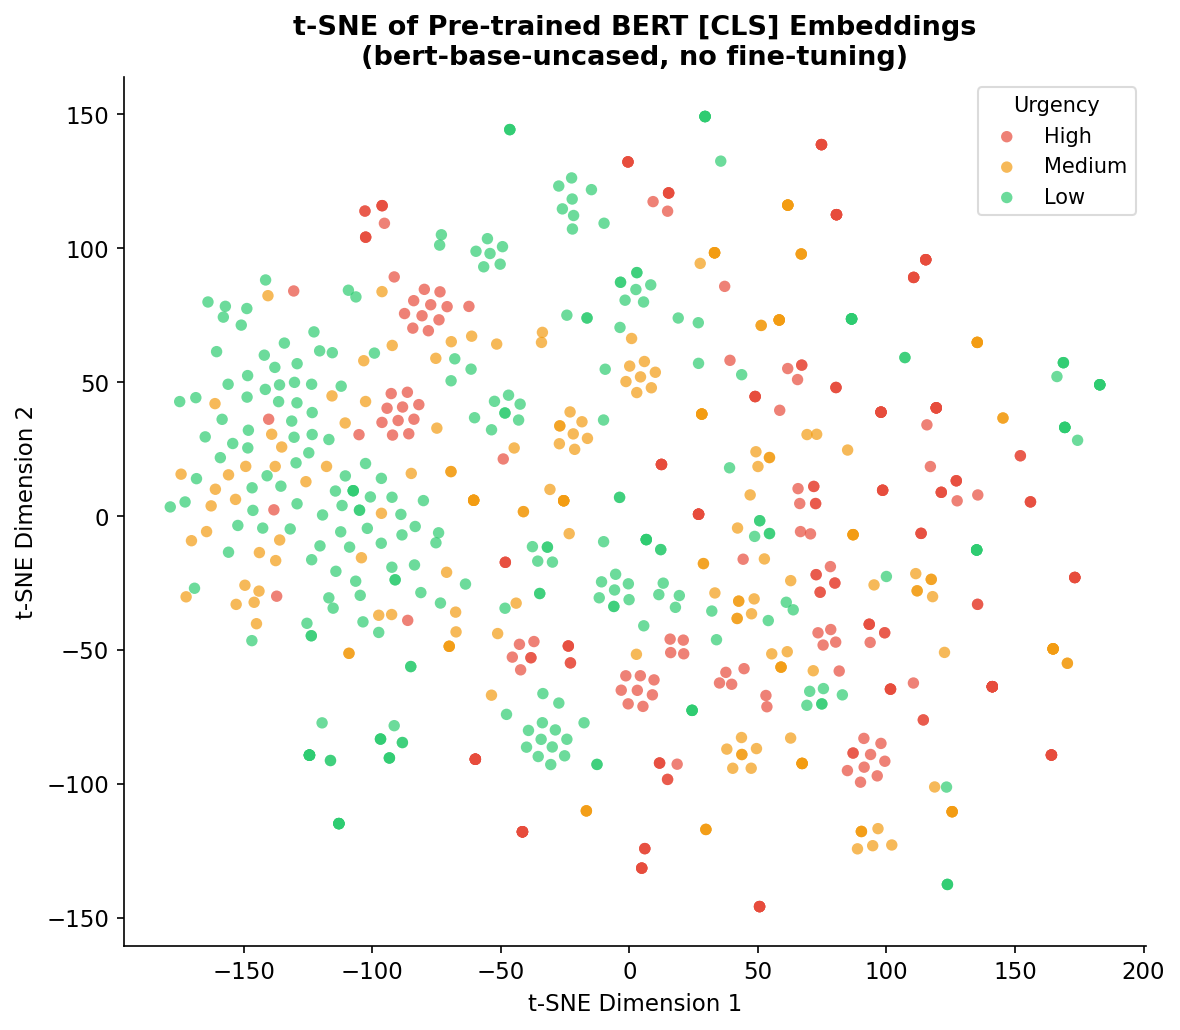

Figure 9 saved.


In [12]:
fig, ax = plt.subplots(figsize=(8, 7))

for label in LABEL_ORDER:
    mask = np.array(all_labels_) == label
    ax.scatter(
        tsne_2d[mask, 0], tsne_2d[mask, 1],
        c=URGENCY_COLORS[label],
        label=LABEL_DISPLAY[label],
        alpha=0.7, s=30, edgecolors='none'
    )

ax.set_title('t-SNE of Pre-trained BERT [CLS] Embeddings\n(bert-base-uncased, no fine-tuning)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Urgency', fontsize=10, title_fontsize=10,
          framealpha=0.8, edgecolor='lightgrey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
for ext in ('svg', 'png', 'pdf'):
    fig.savefig(FIGURES_DIR / f'fig9_tsne_bert_embeddings.{ext}',
                bbox_inches='tight', format=ext)
plt.show()
print('Figure 9 saved.')

---
## 6. Feature Extraction Summary

This cell prints the key numbers referenced in the Week 7 paper section.

In [13]:
pct_within_64  = (token_lengths <= 64).mean()  * 100
pct_within_128 = (token_lengths <= 128).mean() * 100

print('=' * 55)
print('FEATURE EXTRACTION SUMMARY')
print('=' * 55)
print()
print('TF-IDF (baseline features)')
print(f'  Vocabulary size         : {vocab_size}')
print(f'  N-gram range            : (1, 2)')
print(f'  Max features cap        : 500')
print(f'  Sublinear TF scaling    : Yes')
print(f'  Min document frequency  : 2')
print()
print('BERT Tokenisation (bert-base-uncased)')
print(f'  Mean token length       : {token_lengths.mean():.1f}')
print(f'  Median token length     : {np.median(token_lengths):.0f}')
print(f'  Max token length        : {token_lengths.max()}')
print(f'  % covered by max_len=64 : {pct_within_64:.1f}%')
print(f'  % covered by max_len=128: {pct_within_128:.1f}%')
print()
print('Per-class mean token length:')
for label in LABEL_ORDER:
    arr = np.array(lengths_by_class[label])
    print(f'  {LABEL_DISPLAY[label]:<8}: {arr.mean():.1f} ± {arr.std():.1f}')
print()
print('Saved artefacts')
print(f'  models/tfidf_vectorizer.pkl')
print(f'  models/cls_embeddings.npy')
print(f'  results/figures/fig7_tfidf_top_features.*')
print(f'  results/figures/fig8_token_length_distribution.*')
print(f'  results/figures/fig9_tsne_bert_embeddings.*')
print('=' * 55)

FEATURE EXTRACTION SUMMARY

TF-IDF (baseline features)
  Vocabulary size         : 500
  N-gram range            : (1, 2)
  Max features cap        : 500
  Sublinear TF scaling    : Yes
  Min document frequency  : 2

BERT Tokenisation (bert-base-uncased)
  Mean token length       : 15.4
  Median token length     : 15
  Max token length        : 98
  % covered by max_len=64 : 99.7%
  % covered by max_len=128: 100.0%

Per-class mean token length:
  High    : 17.8 ± 6.0
  Medium  : 16.8 ± 6.2
  Low     : 12.4 ± 7.7

Saved artefacts
  models/tfidf_vectorizer.pkl
  models/cls_embeddings.npy
  results/figures/fig7_tfidf_top_features.*
  results/figures/fig8_token_length_distribution.*
  results/figures/fig9_tsne_bert_embeddings.*
